In [ ]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn transformers datasets nltk gensim accelerate
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 98.3 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import pandas as pd

# Loading the Davidson et al. (2017) dataset
url = 'https://raw.githubusercontent.com/t-davidson/hate-speech-and-offensive-language/master/data/labeled_data.csv'
try:
    df = pd.read_csv(url)
    print("Dataset loaded successfully.")
    display(df.head())
except Exception as e:
    print(f"Error loading dataset: {e}")

Dataset loaded successfully.


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


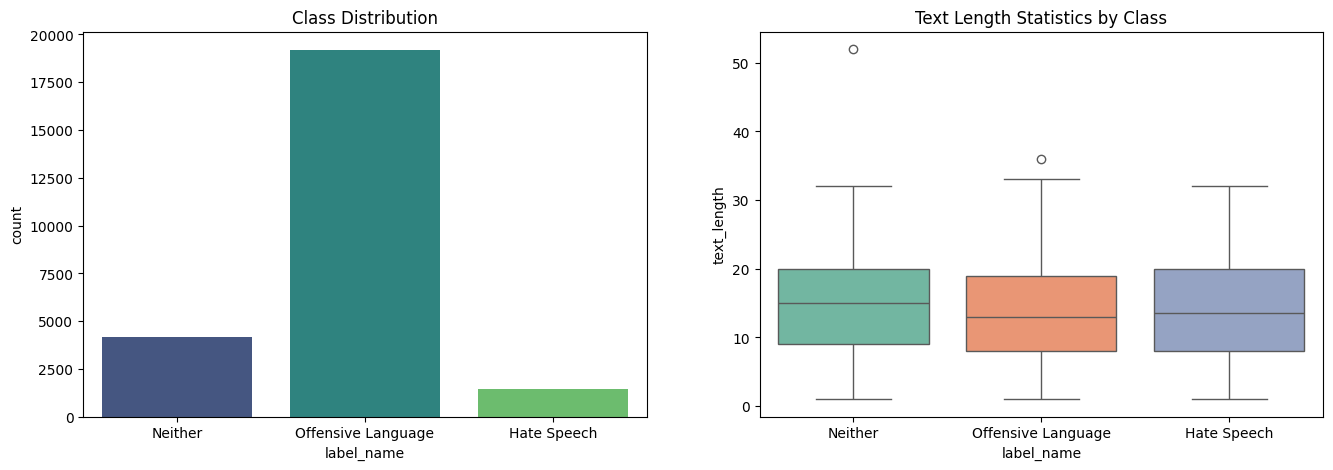

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# EDA 1: Class Distribution & Text Length
class_names = {0: 'Hate Speech', 1: 'Offensive Language', 2: 'Neither'}
df['label_name'] = df['class'].map(class_names)
df['text_length'] = df['tweet'].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(x='label_name', data=df, palette='viridis', hue='label_name', legend=False, ax=ax[0])
ax[0].set_title('Class Distribution')

sns.boxplot(x='label_name', y='text_length', data=df, palette='Set2', hue='label_name', legend=False, ax=ax[1])
ax[1].set_title('Text Length Statistics by Class')
plt.show()

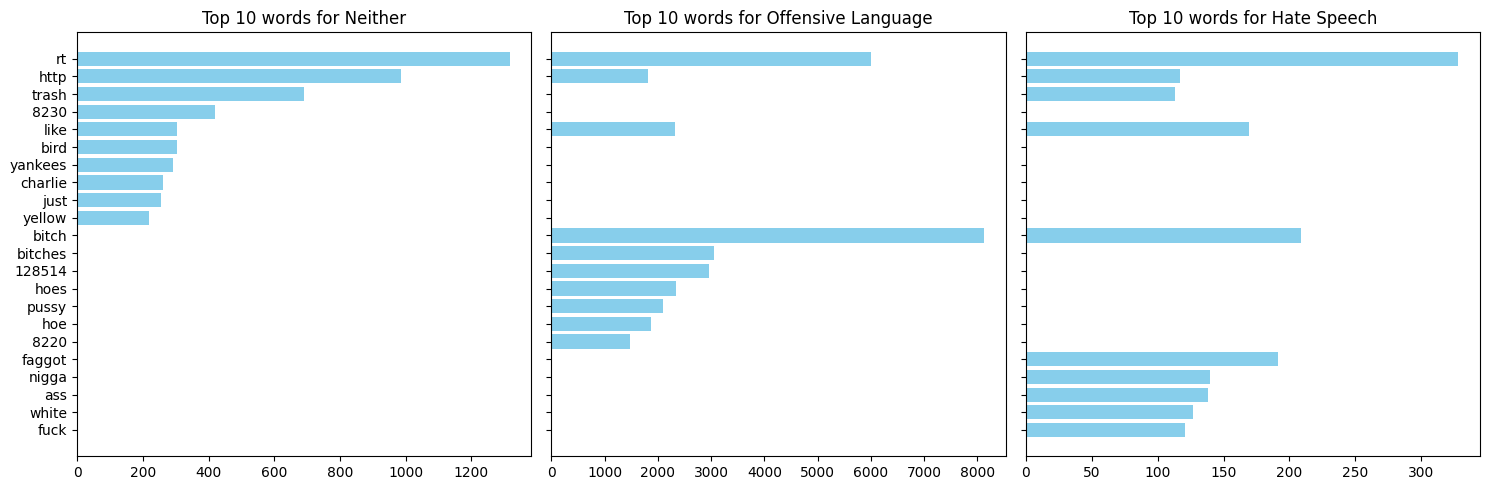

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# EDA 2: Common Terms
def plot_top_words(df, label_col, text_col, n=10):
    labels = df[label_col].unique()
    fig, axes = plt.subplots(1, len(labels), figsize=(15, 5), sharey=True)

    for i, label in enumerate(labels):
        corpus = df[df[label_col] == label][text_col].astype(str)
        vec = CountVectorizer(stop_words='english', max_features=n).fit(corpus)
        bag_of_words = vec.transform(corpus)
        sum_words = bag_of_words.sum(axis=0)
        words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
        words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

        words, freqs = zip(*words_freq)
        axes[i].barh(words, freqs, color='skyblue')
        axes[i].invert_yaxis()
        axes[i].set_title(f'Top {n} words for {label}')

    plt.tight_layout()
    plt.show()

plot_top_words(df, 'label_name', 'tweet', n=10)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Split data
X_train, X_test, y_train, y_test = train_test_split(df['tweet'], df['class'], test_size=0.2, random_state=42, stratify=df['class'])

# Baseline 1: TF-IDF
print("--- Baseline 1: TF-IDF + Logistic Regression ---")
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

lr_tfidf = LogisticRegression(max_iter=1000, random_state=42)
lr_tfidf.fit(X_train_tfidf, y_train)
preds_tfidf = lr_tfidf.predict(X_test_tfidf)
print(classification_report(y_test, preds_tfidf, target_names=['Hate Speech', 'Offensive Language', 'Neither']))

--- Baseline 1: TF-IDF + Logistic Regression ---
                    precision    recall  f1-score   support

       Hate Speech       0.65      0.16      0.26       286
Offensive Language       0.91      0.97      0.94      3838
           Neither       0.87      0.83      0.85       833

          accuracy                           0.90      4957
         macro avg       0.81      0.65      0.68      4957
      weighted avg       0.89      0.90      0.89      4957



In [ ]:
import os
import numpy as np
import gensim.downloader as api
from gensim.models import KeyedVectors
from nltk.tokenize import word_tokenize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from google.colab import drive

print("--- Baseline 2: Word2Vec + Logistic Regression ---")

# Mount Google Drive to save/load the model
drive.mount('/content/drive')
drive_model_path = '/content/drive/MyDrive/word2vec-google-news-300.word2vec'

print("Loading Word2Vec model...")
if os.path.exists(drive_model_path):
    print("Loading model from Google Drive...")
    w2v_model = KeyedVectors.load(drive_model_path)
else:
    print("Downloading model from Gensim API (this will happen only once)...")
    w2v_model = api.load('word2vec-google-news-300')
    print("Saving model to Google Drive for future use...")
    w2v_model.save(drive_model_path)

def get_average_word2vec(text_list, model, num_features=300):
    features = np.zeros((len(text_list), num_features))
    for i, text in enumerate(text_list):
        words = word_tokenize(str(text).lower())
        word_vecs = [model[w] for w in words if w in model]
        if len(word_vecs) > 0:
            features[i] = np.mean(word_vecs, axis=0)
    return features

X_train_w2v = get_average_word2vec(X_train, w2v_model)
X_test_w2v = get_average_word2vec(X_test, w2v_model)

lr_w2v = LogisticRegression(max_iter=1000, random_state=42)
lr_w2v.fit(X_train_w2v, y_train)
preds_w2v = lr_w2v.predict(X_test_w2v)
print(classification_report(y_test, preds_w2v, target_names=['Hate Speech', 'Offensive Language', 'Neither']))

--- Baseline 2: Word2Vec + Logistic Regression ---
Mounted at /content/drive
Loading Word2Vec model...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Saving model to Google Drive for future use...
                    precision    recall  f1-score   support

       Hate Speech       0.55      0.12      0.19       286
Offensive Language       0.90      0.97      0.93      3838
           Neither       0.80      0.74      0.77       833

          accuracy                           0.88      4957
         macro avg       0.75      0.61      0.63      4957
      weighted avg       0.86      0.88      0.86      4957



In [ ]:
import torch
import pandas as pd
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset, ClassLabel
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# Ensure df is loaded to prevent NameError
if 'df' not in globals() and 'df' not in locals():
    url = 'https://raw.githubusercontent.com/t-davidson/hate-speech-and-offensive-language/master/data/labeled_data.csv'
    df = pd.read_csv(url)

print("--- Advanced: BERT Fine-tuning ---")

hf_df = df[['tweet', 'class']].rename(columns={'tweet': 'text', 'class': 'label'})
hf_dataset = Dataset.from_pandas(hf_df)
hf_dataset = hf_dataset.cast_column('label', ClassLabel(num_classes=3))
hf_dataset = hf_dataset.train_test_split(test_size=0.2, seed=42, stratify_by_column='label')

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_datasets = hf_dataset.map(tokenize_function, batched=True)
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_dir='./logs',
    load_best_model_at_end=True,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(labels, preds), 'f1': f1_score(labels, preds, average='weighted')}

trainer = Trainer(
    model=model, args=training_args,
    train_dataset=tokenized_datasets['train'], eval_dataset=tokenized_datasets['test'],
    compute_metrics=compute_metrics,
)
trainer.train()
print("BERT Evaluation Results:", trainer.evaluate())


--- Advanced: BERT Fine-tuning ---


Casting the dataset:   0%|          | 0/24783 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

BERT Evaluation Results: {'eval_loss': 0.2511938810348511, 'eval_accuracy': 0.9118418398224732, 'eval_f1': 0.9091910284885327, 'eval_runtime': 9.4989, 'eval_samples_per_second': 521.85, 'eval_steps_per_second': 32.635, 'epoch': 3.0}


Getting BERT predictions...



--- TF-IDF + Logistic Regression ---
Accuracy: 0.9011 | Macro Precision: 0.8096 | Macro Recall: 0.6541 | Macro F1: 0.6825


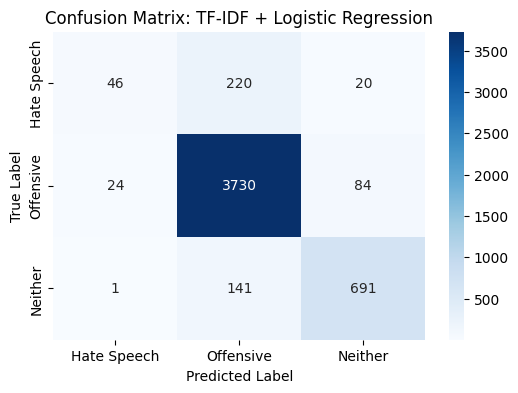


--- Word2Vec + Logistic Regression ---
Accuracy: 0.8786 | Macro Precision: 0.7487 | Macro Recall: 0.6075 | Macro F1: 0.6300


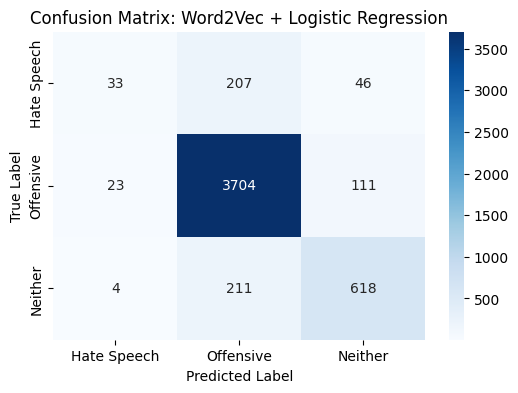


--- BERT Fine-tuned ---
Accuracy: 0.9118 | Macro Precision: 0.7798 | Macro Recall: 0.7442 | Macro F1: 0.7606


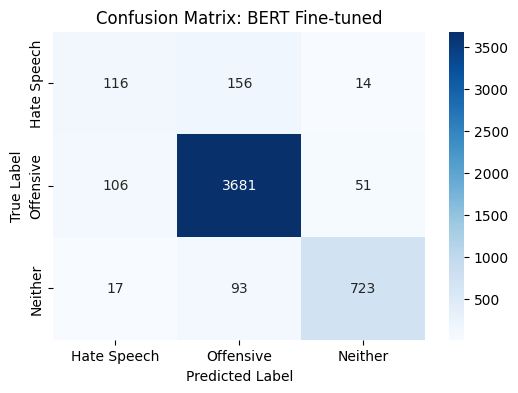


--- Qualitative Review: TF-IDF Misclassifications ---


,text,true_label,prediction
4563,Och hoe wonderbaarlijk dat Jan het alweer met ...,Neither,Offensive Language
863,@WendyDavisTexas @GregAbbott_TX So you support...,Hate Speech,Offensive Language
4376,@jonsweethearts how are you Argie?,Neither,Offensive Language
4818,@RealNoth no wonder your career is in the dump...,Offensive Language,Neither
4336,Why you think all these niggas end up with all...,Hate Speech,Offensive Language
3140,Fucking with these hoes nigga don't be no dumby,Hate Speech,Offensive Language
327,"RT ""@_ThatGAPeach: &amp; alla my niggas hot bo...",Hate Speech,Offensive Language
2170,RT @jjauthor: US ghettos-driven by lib ideolog...,Offensive Language,Neither
4893,"Out of day care, I'm taking a kitty nap on you...",Neither,Offensive Language
2276,@xtruthseekerx_ blaxican,Neither,Offensive Language



--- Qualitative Review: Word2Vec Misclassifications ---


,text,true_label,prediction
1018,I liked a @YouTube video http://t.co/QGNHiLdTT...,Neither,Offensive Language
3519,@denytheprophecy thanks for ignoring my texts fag,Hate Speech,Offensive Language
4663,I'm not really a phone kinda guy.. I actually ...,Neither,Offensive Language
686,I never had any friends the entire time I live...,Hate Speech,Neither
1600,RT @Kidd_BravO615: Nigga wanna bitch about a p...,Hate Speech,Offensive Language
2375,stfu redneck white trash head ass,Offensive Language,Hate Speech
83,@LaBugg09 &#128514;&#128514; my fault it sound...,Neither,Offensive Language
3934,Most niccas broke but always n the limelight,Hate Speech,Offensive Language
695,"RT @dynamite8503: ""Why y'all doing the ALS cha...",Neither,Offensive Language
2915,RT @urbandictionary: @The2kGod nigger: A fully...,Offensive Language,Hate Speech



--- Qualitative Review: BERT Misclassifications ---


,text,true_label,prediction
4369,"The nations know who we are, but we rather be ...",Hate Speech,Offensive Language
888,fags god damn,Offensive Language,Hate Speech
2964,Gabby is hella ghetto,Offensive Language,Neither
3284,"Yeah.. They heard I'm fucking nuts, like the s...",Offensive Language,Hate Speech
3420,Lmao RT @MoeMartin44 Yo a cooned out nigger boy,Offensive Language,Hate Speech
3045,@PlasticDom can we plz go to Starbucks and do ...,Offensive Language,Neither
2292,@TheREALJB1RD Now beaners drive em.,Offensive Language,Hate Speech
916,RT @itsclaribelyo: Swag fags are now hibernati...,Offensive Language,Hate Speech
4901,RT @uncledaddy69: @weakenednachos California's...,Hate Speech,Offensive Language
4492,"RT @seanmdav: Since I know you're wondering, @...",Neither,Hate Speech


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support

# 1. Get BERT Predictions
print("Getting BERT predictions...")
bert_output = trainer.predict(tokenized_datasets['test'])
preds_bert = np.argmax(bert_output.predictions, axis=-1)
y_test_bert = np.array(tokenized_datasets['test']['label'])

# 2. Evaluation Function for Metrics & Confusion Matrix
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    print(f"\n--- {model_name} ---")
    print(f"Accuracy: {acc:.4f} | Macro Precision: {precision:.4f} | Macro Recall: {recall:.4f} | Macro F1: {f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Hate Speech', 'Offensive', 'Neither'],
                yticklabels=['Hate Speech', 'Offensive', 'Neither'])
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Evaluate all three models
evaluate_model(y_test, preds_tfidf, "TF-IDF + Logistic Regression")
evaluate_model(y_test, preds_w2v, "Word2Vec + Logistic Regression")
evaluate_model(y_test_bert, preds_bert, "BERT Fine-tuned")

# 3. Qualitative Review of Misclassified Examples
def get_misclassified(texts, y_true, y_pred, n=10):
    df_eval = pd.DataFrame({'text': texts, 'true_label': y_true, 'prediction': y_pred})
    # Map numerical labels back to text for readability
    label_map = {0: 'Hate Speech', 1: 'Offensive Language', 2: 'Neither'}
    df_eval['true_label'] = df_eval['true_label'].map(label_map)
    df_eval['prediction'] = df_eval['prediction'].map(label_map)

    misclassified = df_eval[df_eval['true_label'] != df_eval['prediction']]
    return misclassified.sample(n=min(n, len(misclassified)), random_state=42)

print("\n=======================================================")
print("--- Qualitative Review: TF-IDF Misclassifications ---")
display(get_misclassified(X_test.values, y_test.values, preds_tfidf, n=10))

print("\n--- Qualitative Review: Word2Vec Misclassifications ---")
display(get_misclassified(X_test.values, y_test.values, preds_w2v, n=10))

print("\n--- Qualitative Review: BERT Misclassifications ---")
display(get_misclassified(tokenized_datasets['test']['text'], y_test_bert, preds_bert, n=10))
